# MNIST Data, Heterogeneity in FL

### Setup

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from torch.autograd import Variable
import numpy as np
import random
import copy
import time
from functools import reduce
from torchsummary import summary
import matplotlib.pyplot as plt
import csv

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [3]:
import math
import torch
from torch.optim import Optimizer


class SGD(Optimizer):
    
    def __init__(self, params, lr, momentum=0, dampening=0,
                 weight_decay=0, nesterov=False):
        if lr < 0.0:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if momentum < 0.0:
            raise ValueError("Invalid momentum value: {}".format(momentum))
        if weight_decay < 0.0:
            raise ValueError("Invalid weight_decay value: {}".format(weight_decay))

        defaults = dict(lr=lr, momentum=momentum, dampening=dampening,
                        weight_decay=weight_decay, nesterov=nesterov)
        if nesterov and (momentum <= 0 or dampening != 0):
            raise ValueError("Nesterov momentum requires a momentum and zero dampening")
        super(SGD, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(SGD, self).__setstate__(state)
        for group in self.param_groups:
            group.setdefault('nesterov', False)

    def step(self, grads, closure=None):
        """Performs a single optimization step.
        Arguments:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            weight_decay = group['weight_decay']
            momentum = group['momentum']
            dampening = group['dampening']
            nesterov = group['nesterov']

            for i,p in enumerate(group['params']):
#                 if p.grad is None:
#                     continue
                
                d_p = grads[i]
                
                if weight_decay != 0:
                    d_p.add_(weight_decay, p.data)
                if momentum != 0:
                    param_state = self.state[p]
                    if 'momentum_buffer' not in param_state:
                        buf = param_state['momentum_buffer'] = torch.clone(d_p).detach()
                    else:
                        buf = param_state['momentum_buffer']
                        buf.mul_(momentum).add_(1 - dampening, d_p)
                    if nesterov:
                        d_p = d_p.add(momentum, buf)
                    else:
                        d_p = buf

                p.data.add_(-group['lr'], d_p)

        return loss

In [4]:
class cnn(nn.Module):
    def __init__(self):
        super(cnn, self).__init__()
        self.conv1 = nn.Conv2d(1, 30, 5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(30, 50, 5)
        self.pool2 = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(800, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [5]:
criterion = nn.CrossEntropyLoss()

### Load dataset

In [6]:
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_data = torch.utils.data.DataLoader(trainset, batch_size=60000, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_data = torch.utils.data.DataLoader(testset, batch_size=5000, shuffle=False)

### Adjustable parameters

# ===============================
# bias = 0.1, # of clients = 15
# ===============================

In [7]:
bias = 0.1
num_workers = 15 # number of clients
bias_weight = bias
other_group_size = (1 - bias_weight) / 9.
worker_per_group = num_workers / 10

### Distributing data, changes when bias changes

In [8]:
#This code block is distributing the data amongst the clients. This is called the fang distribution
each_worker_data = [[] for _ in range(num_workers)]
each_worker_label = [[] for _ in range(num_workers)]
for i, (data, labels) in enumerate(train_data):
    for (x, y) in zip(data, labels):
        #print(np.shape(x))
        
        # assign a data point to a group
        upper_bound = (y) * (1 - bias_weight) / 9. + bias_weight
        lower_bound = (y) * (1 - bias_weight) / 9.
        rd = np.random.random_sample()

        if rd > upper_bound:
            worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)
        elif rd < lower_bound:
            worker_group = int(np.floor(rd / other_group_size))
        else:
            worker_group = y

        # assign a data point to a worker
        rd = np.random.random_sample()
        selected_worker = int(worker_group * worker_per_group + int(np.floor(rd * worker_per_group)))
        each_worker_data[selected_worker].append(x)
        each_worker_label[selected_worker].append(y)

/tmp/ipykernel_13480/904806604.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)


In [9]:
each_worker_data = [torch.stack(each_worker) for each_worker in each_worker_data]
each_worker_label = [torch.stack(each_worker) for each_worker in each_worker_label]

In [10]:
seed = 3
random_order = np.random.RandomState(seed=seed).permutation(num_workers)
each_worker_data = [each_worker_data[i] for i in random_order]
each_worker_label = [each_worker_label[i] for i in random_order]

In [11]:
each_worker_data = [each_worker.to(device) for each_worker in each_worker_data]
each_worker_label = [each_worker.to(device) for each_worker in each_worker_label]

In [12]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(gain)

### Main Code

In [22]:
accuracy_bias_0_1 = []

In [23]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_1.append(correct/total)

0 0.0744
1 0.1253
2 0.1559
3 0.2091
4 0.2488
5 0.2846
6 0.3209
7 0.3508
8 0.3774
9 0.405
10 0.4317
11 0.4521
12 0.4697
13 0.4858
14 0.5022
15 0.5178
16 0.5297
17 0.5427
18 0.5535
19 0.5616
20 0.5716
21 0.5816
22 0.59
23 0.5973
24 0.6044
25 0.6123
26 0.6171
27 0.6219
28 0.6295
29 0.6352
30 0.6407
31 0.6471
32 0.6517
33 0.6566
34 0.6613
35 0.6668
36 0.6722
37 0.6761
38 0.6805
39 0.6839
40 0.6892
41 0.6934
42 0.6972
43 0.7007
44 0.7049
45 0.7084
46 0.712
47 0.7156
48 0.72
49 0.7228
50 0.7259
51 0.7295
52 0.732
53 0.7347
54 0.738
55 0.7411
56 0.7449
57 0.749
58 0.7523
59 0.7555
60 0.759
61 0.7619
62 0.7646
63 0.7671
64 0.7703
65 0.7727
66 0.7761
67 0.7787
68 0.781
69 0.7839
70 0.7863
71 0.7888
72 0.7904
73 0.7938
74 0.7966
75 0.7986
76 0.7993
77 0.8019
78 0.8036
79 0.8049
80 0.8062
81 0.808
82 0.8097
83 0.8115
84 0.8133
85 0.8144
86 0.816
87 0.8173
88 0.8185
89 0.8199
90 0.8209
91 0.8224
92 0.8235
93 0.8255
94 0.8271
95 0.8289
96 0.83
97 0.8307
98 0.8321
99 0.8328
CPU times: user 1min 21s,

### Displaying results, bias = 0.1. # of clients = 15

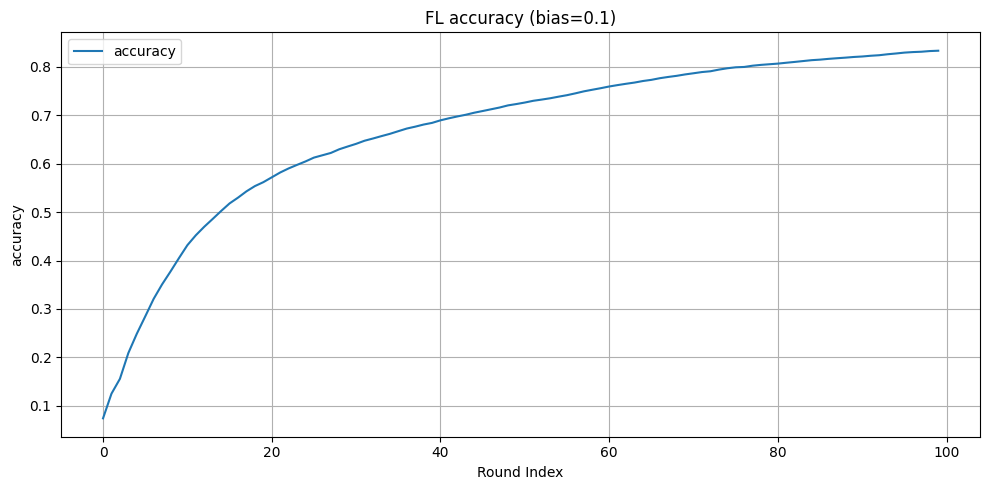

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label='accuracy')
plt.title('FL accuracy (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Lie attack on bias = 0.1

In [26]:
def lie_attack(all_updates, z):

    avg = torch.mean(all_updates, dim=0)

    std = torch.std(all_updates, dim=0)

    attacked_update = avg + z * std

    return attacked_update

In [27]:
accuracy_bias_0_1_lie_attack_redo = []
print(accuracy_bias_0_1_lie_attack_redo)

[]


In [28]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
z = 1.5  # Adjust attack strength as needed

for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads= lie_attack(user_grads, z)
    #agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_1_lie_attack_redo.append(correct/total)

0 0.1016
1 0.1356
2 0.1677
3 0.1823
4 0.2001
5 0.2131
6 0.2255
7 0.245
8 0.2641
9 0.284
10 0.3048
11 0.3244
12 0.3445
13 0.3632
14 0.3808
15 0.399
16 0.4147
17 0.429
18 0.4427
19 0.4556
20 0.4668
21 0.4801
22 0.4886
23 0.4985
24 0.5085
25 0.5174
26 0.5259
27 0.533
28 0.5425
29 0.5527
30 0.5606
31 0.5686
32 0.5745
33 0.5823
34 0.5898
35 0.5963
36 0.6017
37 0.6078
38 0.6142
39 0.6186
40 0.624
41 0.6292
42 0.6335
43 0.6392
44 0.6431
45 0.6475
46 0.6525
47 0.6577
48 0.6618
49 0.666
50 0.6705
51 0.6737
52 0.6774
53 0.6807
54 0.6833
55 0.6875
56 0.6925
57 0.6959
58 0.6995
59 0.7029
60 0.7064
61 0.7104
62 0.7135
63 0.7166
64 0.7205
65 0.7227
66 0.7264
67 0.7309
68 0.7342
69 0.7368
70 0.7411
71 0.7436
72 0.7463
73 0.7498
74 0.7531
75 0.7562
76 0.7583
77 0.76
78 0.7626
79 0.7658
80 0.768
81 0.7698
82 0.7711
83 0.7744
84 0.7768
85 0.7793
86 0.7809
87 0.7826
88 0.7854
89 0.7874
90 0.7889
91 0.7917
92 0.7939
93 0.7956
94 0.7971
95 0.798
96 0.7998
97 0.8018
98 0.8034
99 0.8046
CPU times: user 1min 

### LIE Attack, bias = 0.1. # of clients = 15

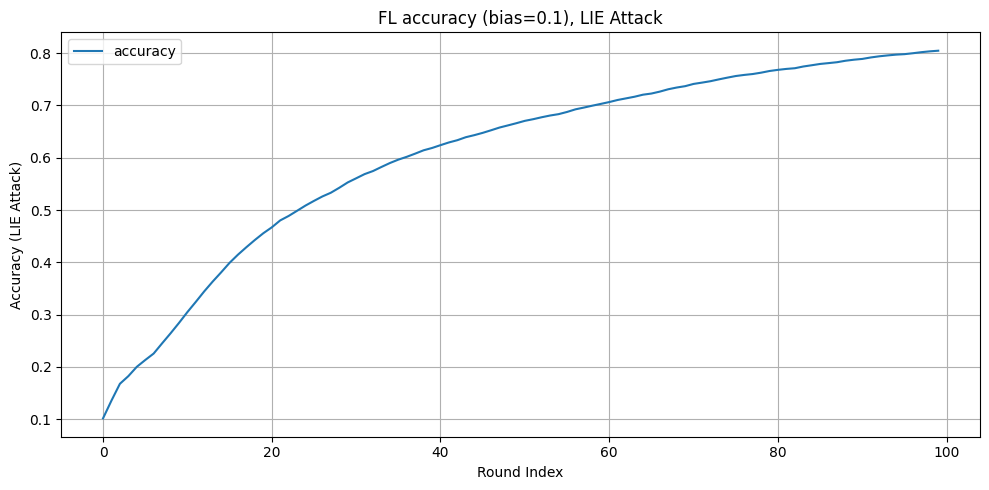

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1_lie_attack_redo, label='accuracy')
plt.title('FL accuracy (bias=0.1), LIE Attack')
plt.xlabel('Round Index')
plt.ylabel('Accuracy (LIE Attack)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### both

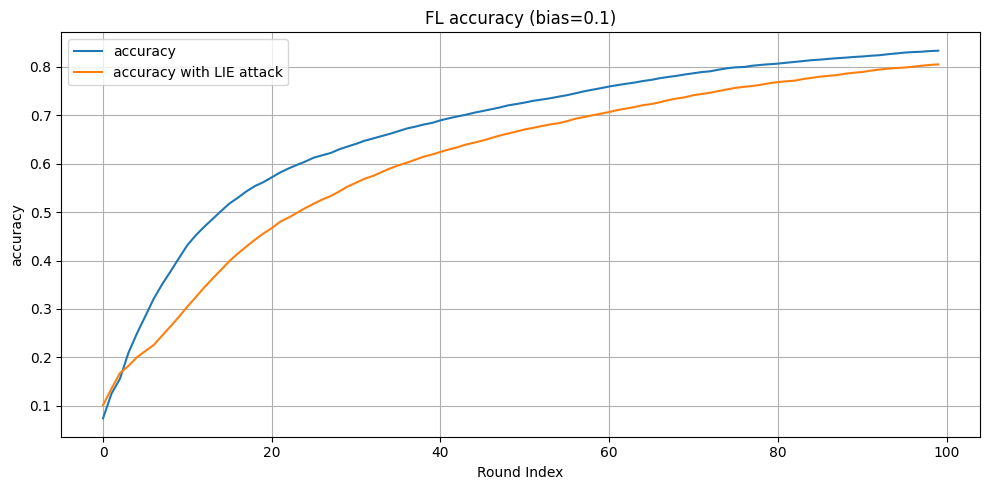

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label='accuracy')
#plt.plot(accuracy_bias_0_1_lie_attack, label='accuracy with LIE attack')
plt.plot(accuracy_bias_0_1_lie_attack_redo, label='accuracy with LIE attack')
plt.title('FL accuracy (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### full_trim attack, bias = 0.1

In [31]:
accuracy_bias_0_1_full_trim_attack = []
print(accuracy_bias_0_1_full_trim_attack)

[]


In [32]:
#Static 
#This is the attack.
def full_trim(v, f):
    '''
    Full-knowledge Trim attack. w.l.o.g., we assume the first f worker devices are compromised.
    v: the list of squeezed gradients
    f: the number of compromised worker devices
    '''
    # first compute the statistics
    vi_shape = v[0].unsqueeze(0).T.shape
    v_tran = v.T
#     v_tran = nd.concat(*v, dim=1)
    
    maximum_dim = torch.max(v_tran, dim=1)
    maximum_dim = maximum_dim[0].reshape(vi_shape)
    minimum_dim = torch.min(v_tran, dim=1)
    minimum_dim = minimum_dim[0].reshape(vi_shape)
    direction = torch.sign(torch.sum(v_tran, dim=-1, keepdims=True))
    directed_dim = (direction > 0) * minimum_dim + (direction < 0) * maximum_dim

    for i in range(f):
        # apply attack to compromised worker devices with randomness
        random_12 = 2
        tmp = directed_dim * ((direction * directed_dim > 0) / random_12 + (direction * directed_dim < 0) * random_12)
        tmp = tmp.squeeze()
        v[i] = tmp
    return v

In [33]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    agg_grads = torch.mean(user_grads, dim=0)
    #agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_1_full_trim_attack.append(correct/total)

0 0.1191
1 0.1202
2 0.1338
3 0.1545
4 0.1733
5 0.187
6 0.2
7 0.2122
8 0.2268
9 0.2382
10 0.2501
11 0.2584
12 0.2671
13 0.2755
14 0.2862
15 0.2955
16 0.3078
17 0.3179
18 0.3263
19 0.3363
20 0.3472
21 0.3575
22 0.3675
23 0.3765
24 0.3854
25 0.394
26 0.4027
27 0.4101
28 0.4185
29 0.427
30 0.435
31 0.4423
32 0.4486
33 0.4565
34 0.4652
35 0.4717
36 0.4779
37 0.484
38 0.4905
39 0.4975
40 0.5016
41 0.5071
42 0.5125
43 0.5175
44 0.5236
45 0.5297
46 0.5357
47 0.5406
48 0.545
49 0.5502
50 0.5546
51 0.5589
52 0.5642
53 0.5691
54 0.5724
55 0.5758
56 0.5806
57 0.5839
58 0.5877
59 0.593
60 0.5967
61 0.6008
62 0.6044
63 0.6083
64 0.6118
65 0.6153
66 0.6201
67 0.6242
68 0.6273
69 0.6311
70 0.6358
71 0.6386
72 0.6429
73 0.6463
74 0.6509
75 0.6535
76 0.6579
77 0.6609
78 0.6646
79 0.6679
80 0.6721
81 0.6755
82 0.6782
83 0.6822
84 0.6857
85 0.6892
86 0.6938
87 0.6959
88 0.7005
89 0.7052
90 0.7092
91 0.7121
92 0.7164
93 0.7207
94 0.7246
95 0.7278
96 0.7304
97 0.7337
98 0.7368
99 0.7403
CPU times: user 1min

### full_trim attack, bias = 0.1, 15 clients

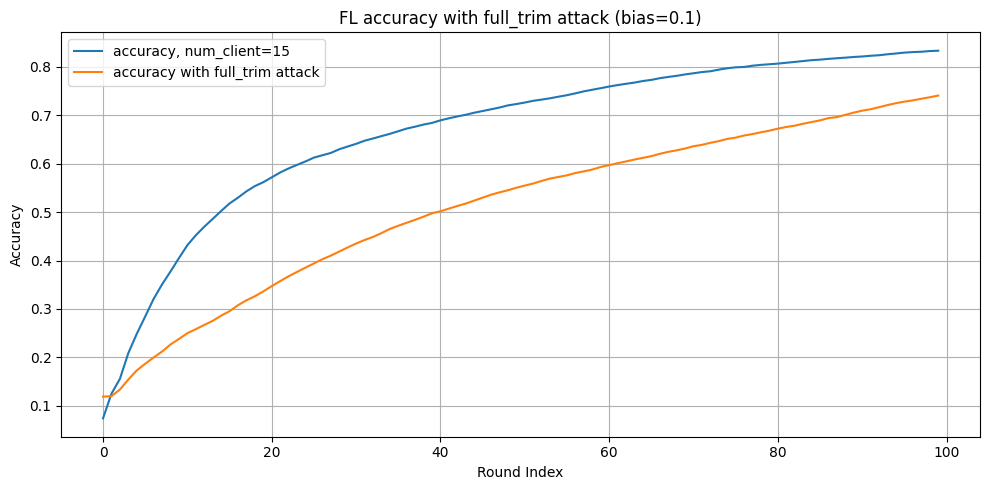

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_1_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### now with 10 clients, normal run, no full_trim attack, save to accuracies_2

In [43]:
accuracy_bias_0_1_clients_10 = []

In [44]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(10):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_1_clients_10.append(correct/total)

0 0.0782
1 0.0919
2 0.1137
3 0.1417
4 0.1746
5 0.1988
6 0.2173
7 0.2365
8 0.2622
9 0.2744
10 0.2861
11 0.3002
12 0.3152
13 0.3288
14 0.343
15 0.3583
16 0.3718
17 0.3901
18 0.4048
19 0.4204
20 0.4355
21 0.4494
22 0.4629
23 0.4764
24 0.4894
25 0.5007
26 0.5138
27 0.5233
28 0.5323
29 0.5407
30 0.5504
31 0.5607
32 0.5683
33 0.5758
34 0.5849
35 0.5919
36 0.5997
37 0.6069
38 0.614
39 0.6201
40 0.6261
41 0.6327
42 0.6387
43 0.6426
44 0.6485
45 0.6531
46 0.6578
47 0.6634
48 0.6674
49 0.6708
50 0.6751
51 0.6788
52 0.6827
53 0.6862
54 0.6904
55 0.693
56 0.6972
57 0.7001
58 0.7034
59 0.7066
60 0.7086
61 0.7113
62 0.7144
63 0.7184
64 0.7209
65 0.7239
66 0.7259
67 0.7293
68 0.7325
69 0.7353
70 0.7389
71 0.7421
72 0.7443
73 0.7468
74 0.7497
75 0.7522
76 0.754
77 0.7558
78 0.7582
79 0.7605
80 0.7635
81 0.7656
82 0.7676
83 0.769
84 0.7715
85 0.7735
86 0.7747
87 0.7769
88 0.7793
89 0.7818
90 0.7837
91 0.7844
92 0.7863
93 0.7879
94 0.7886
95 0.7906
96 0.7924
97 0.7943
98 0.7963
99 0.7978
CPU times: user

### 3 graphs for full_trim, bias = 0.1

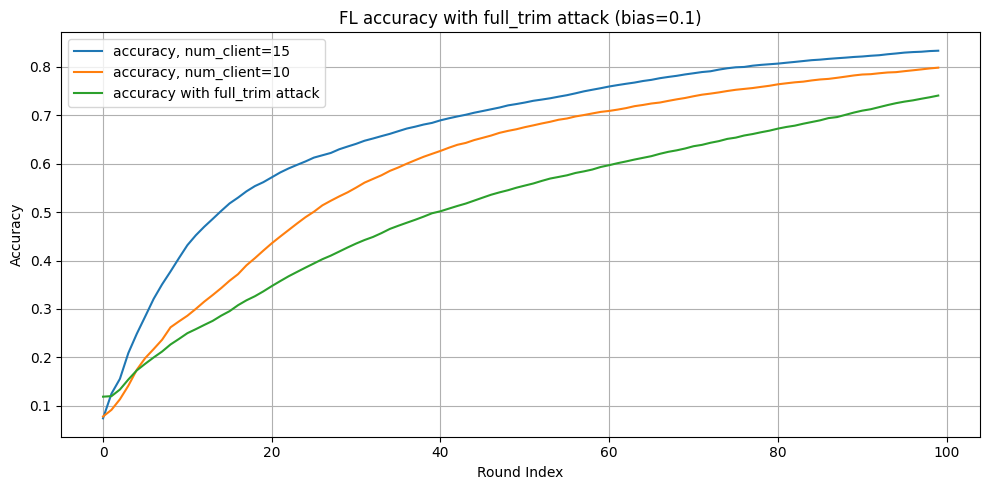

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_1_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_1_full_trim_attack, label='accuracy with full_trim attack')


plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### implementing full_trim defense

In [50]:
#This is the defense. It performs dimension-wise filtering of the model updates i.e., it chops off the outliers.
def tr_mean(all_updates, n_attackers):
    sorted_updates = torch.sort(all_updates, 0)[0]
    out = torch.mean(sorted_updates[n_attackers:-n_attackers], 0) if n_attackers else torch.mean(sorted_updates,0)
    return out

In [54]:
accuracy_bias_0_1_full_trim_defense = []

In [55]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    #agg_grads = torch.mean(user_grads, dim=0)
    agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_1_full_trim_defense.append(correct/total)

0 0.0823
1 0.0672
2 0.0838
3 0.0949
4 0.1109
5 0.1273
6 0.151
7 0.1818
8 0.2079
9 0.2356
10 0.2612
11 0.2891
12 0.3155
13 0.3401
14 0.3652
15 0.3891
16 0.4116


KeyboardInterrupt: 

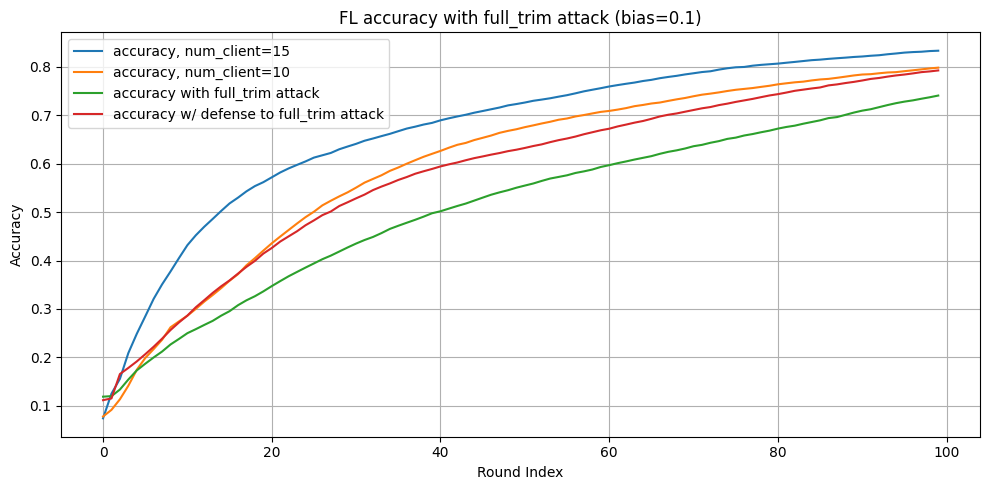

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_1_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_1_full_trim_attack, label='accuracy with full_trim attack')
plt.plot(accuracy_bias_0_1_full_trim_defense, label='accuracy w/ defense to full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# bias = 0.5, # of clients = 15
# ===============================

In [56]:
bias = 0.5
num_workers = 15 # number of clients
bias_weight = bias
other_group_size = (1 - bias_weight) / 9.
worker_per_group = num_workers / 10

In [57]:
#This code block is distributing the data amongst the clients. This is called the fang distribution
each_worker_data = [[] for _ in range(num_workers)]
each_worker_label = [[] for _ in range(num_workers)]
for i, (data, labels) in enumerate(train_data):
    for (x, y) in zip(data, labels):
        #print(np.shape(x))
        
        # assign a data point to a group
        upper_bound = (y) * (1 - bias_weight) / 9. + bias_weight
        lower_bound = (y) * (1 - bias_weight) / 9.
        rd = np.random.random_sample()

        if rd > upper_bound:
            worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)
        elif rd < lower_bound:
            worker_group = int(np.floor(rd / other_group_size))
        else:
            worker_group = y

        # assign a data point to a worker
        rd = np.random.random_sample()
        selected_worker = int(worker_group * worker_per_group + int(np.floor(rd * worker_per_group)))
        each_worker_data[selected_worker].append(x)
        each_worker_label[selected_worker].append(y)

/tmp/ipykernel_13480/904806604.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)


In [58]:
each_worker_data = [torch.stack(each_worker) for each_worker in each_worker_data]
each_worker_label = [torch.stack(each_worker) for each_worker in each_worker_label]

In [59]:
seed = 3
random_order = np.random.RandomState(seed=seed).permutation(num_workers)
each_worker_data = [each_worker_data[i] for i in random_order]
each_worker_label = [each_worker_label[i] for i in random_order]

In [60]:
each_worker_data = [each_worker.to(device) for each_worker in each_worker_data]
each_worker_label = [each_worker.to(device) for each_worker in each_worker_label]

### main code, save to accuracy_bias_0_5

In [64]:
accuracy_bias_0_5 = []
print(accuracy_bias_0_5)

[]


In [65]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5.append(correct/total)

0 0.097
1 0.1369
2 0.1374
3 0.1452
4 0.1756
5 0.2107
6 0.2378
7 0.2646
8 0.2885
9 0.3098
10 0.3314
11 0.3542
12 0.3741
13 0.3931
14 0.4142
15 0.4316
16 0.4496
17 0.4686
18 0.4835
19 0.4984
20 0.5134
21 0.5298
22 0.543
23 0.5551
24 0.5676
25 0.5769
26 0.5865
27 0.597
28 0.6048
29 0.6119
30 0.6182
31 0.625
32 0.6315
33 0.6375
34 0.6443
35 0.6505
36 0.657
37 0.6623
38 0.6676
39 0.6728
40 0.6785
41 0.6843
42 0.6908
43 0.6963
44 0.7004
45 0.7049
46 0.7098
47 0.7137
48 0.7183
49 0.7228
50 0.7266
51 0.7299
52 0.7347
53 0.7385
54 0.741
55 0.7446
56 0.7481
57 0.7507
58 0.7535
59 0.7564
60 0.7588
61 0.7611
62 0.7646
63 0.7673
64 0.7684
65 0.7704
66 0.7719
67 0.7737
68 0.7756
69 0.7781
70 0.7807
71 0.7825
72 0.7835
73 0.7853
74 0.7875
75 0.79
76 0.7928
77 0.7941
78 0.7958
79 0.7984
80 0.8
81 0.8021
82 0.8038
83 0.8055
84 0.8079
85 0.8089
86 0.8101
87 0.8121
88 0.8132
89 0.8149
90 0.8164
91 0.8179
92 0.8195
93 0.8209
94 0.8215
95 0.8226
96 0.8245
97 0.8258
98 0.827
99 0.8282
CPU times: user 1min 5

### Displaying results, bias = 0.5. # of clients = 15

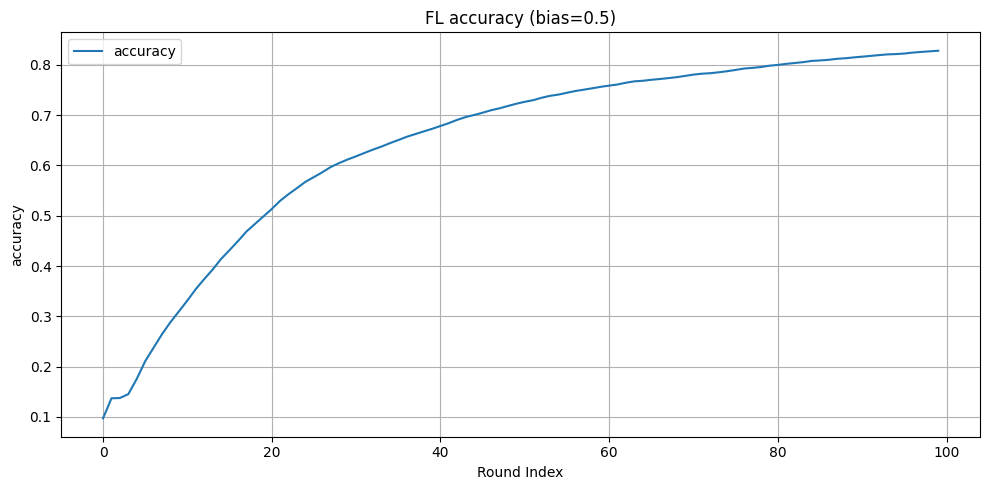

In [66]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy')
plt.title('FL accuracy (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Lie attack on bias = 0.5

In [75]:
accuracy_bias_0_5_lie_attack = []
print(accuracy_bias_0_5_lie_attack)

[]


### saving to accuracy_bias_0_5_lie_attack

In [76]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
z = 1.5  # Adjust attack strength as needed

for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads= lie_attack(user_grads, z)
    #agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5_lie_attack.append(correct/total)

0 0.0978
1 0.1505
2 0.1282
3 0.1229
4 0.1259
5 0.1314
6 0.1372
7 0.1385
8 0.1372
9 0.1351
10 0.1292
11 0.1248
12 0.1199
13 0.1173
14 0.1135
15 0.1102
16 0.108
17 0.106
18 0.1042
19 0.103
20 0.1016
21 0.1013
22 0.1009
23 0.0999
24 0.0995
25 0.0994
26 0.0993
27 0.0991
28 0.0987
29 0.0985
30 0.0984
31 0.0981
32 0.0981
33 0.098
34 0.0979
35 0.0978
36 0.0978
37 0.0977
38 0.0977
39 0.0977
40 0.0977
41 0.0977
42 0.0977
43 0.0977
44 0.0977
45 0.0977
46 0.0976
47 0.0976
48 0.0976
49 0.0976
50 0.0976
51 0.0976
52 0.0976
53 0.0976
54 0.0976
55 0.0976
56 0.0975
57 0.0975
58 0.0975
59 0.0975
60 0.0975
61 0.0975
62 0.0975
63 0.0975
64 0.0975
65 0.0975
66 0.0975
67 0.0975
68 0.0975
69 0.0974
70 0.0974
71 0.0974
72 0.0974
73 0.0974
74 0.0975
75 0.0975
76 0.0975
77 0.0975
78 0.0975
79 0.0975
80 0.0975
81 0.0976
82 0.0976
83 0.0977
84 0.0978
85 0.0979
86 0.0979
87 0.0979
88 0.0979
89 0.098
90 0.0981
91 0.0981
92 0.0982
93 0.0984
94 0.0984
95 0.0985
96 0.0985
97 0.0986
98 0.0986
99 0.099
CPU times: user 

### LIE Attack, bias = 0.5. # of clients = 15

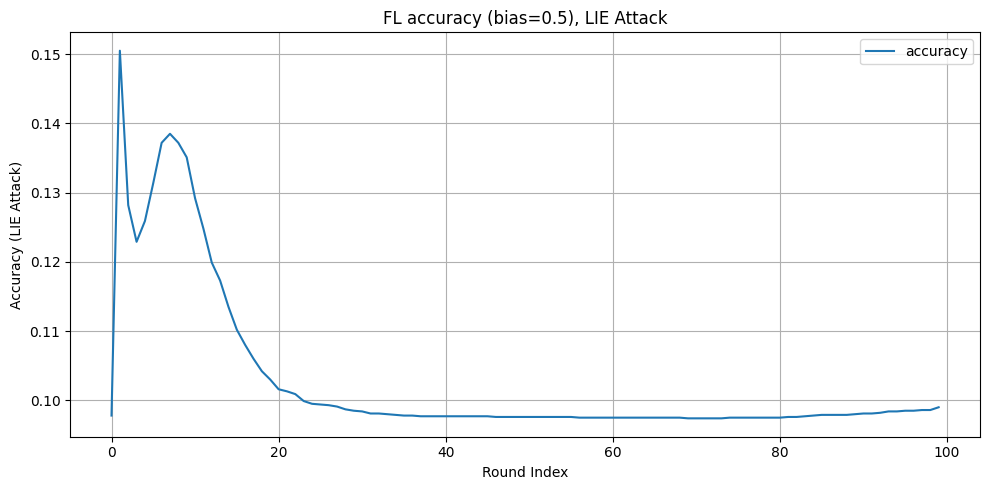

In [77]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5_lie_attack, label='accuracy')
plt.title('FL accuracy (bias=0.5), LIE Attack')
plt.xlabel('Round Index')
plt.ylabel('Accuracy (LIE Attack)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### both

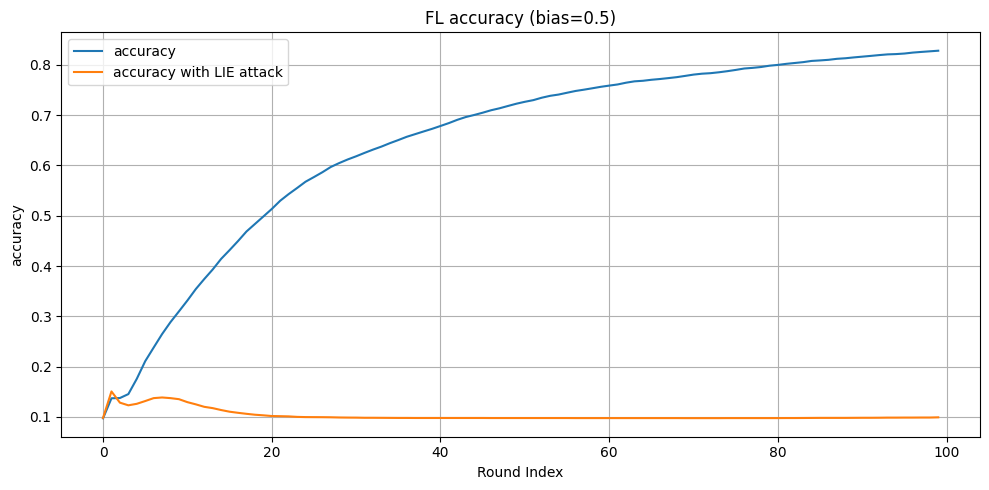

In [78]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy')
plt.plot(accuracy_bias_0_5_lie_attack, label='accuracy with LIE attack')
plt.title('FL accuracy (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### full_trim attack, bias = 0.5

In [79]:
accuracy_bias_0_5_full_trim_attack = []
print(accuracy_bias_0_5_full_trim_attack)

[]


In [80]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    agg_grads = torch.mean(user_grads, dim=0)
    #agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5_full_trim_attack.append(correct/total)

0 0.1048
1 0.1096
2 0.1315
3 0.1494
4 0.1534
5 0.1619
6 0.1669
7 0.1722
8 0.1802
9 0.1868
10 0.1924
11 0.1979
12 0.2029
13 0.2089
14 0.2143
15 0.218
16 0.2229
17 0.2262
18 0.2295
19 0.2323
20 0.2357
21 0.2382
22 0.2401
23 0.2421
24 0.244
25 0.2459
26 0.2486
27 0.25
28 0.2515
29 0.2529
30 0.255
31 0.2575
32 0.2588
33 0.2605
34 0.2618
35 0.2636
36 0.2656
37 0.2669
38 0.2693
39 0.2711
40 0.273
41 0.2742
42 0.275
43 0.2762
44 0.2785
45 0.2798
46 0.2816
47 0.2828
48 0.2839
49 0.285
50 0.2857
51 0.2873
52 0.2885
53 0.2904
54 0.291
55 0.2933
56 0.2939
57 0.2964
58 0.2988
59 0.3003
60 0.3016
61 0.3041
62 0.3061
63 0.3088
64 0.3108
65 0.3137
66 0.316
67 0.3198
68 0.3237
69 0.329
70 0.3338
71 0.3408
72 0.3429
73 0.3505
74 0.3557
75 0.3502
76 0.349
77 0.2711
78 0.4734
79 0.3848
80 0.3535
81 0.3083
82 0.3585
83 0.5697
84 0.3154
85 0.4439
86 0.4052
87 0.4778
88 0.3003
89 0.4124
90 0.4562
91 0.3529
92 0.5784
93 0.3193
94 0.5391
95 0.3967
96 0.47
97 0.3621
98 0.6506
99 0.4268
CPU times: user 1min 50s

### full_trim attack, bias = 0.5, 15 clients

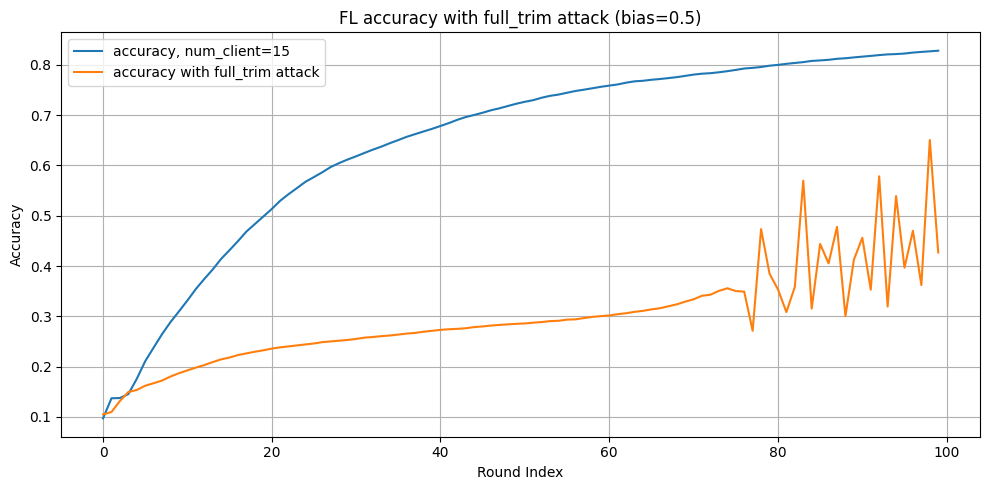

In [81]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_5_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### now with 10 clients, normal run, no full_trim attack, save to accuracy_bias_0_5_clients_10

In [82]:
accuracy_bias_0_5_clients_10 = []
print(accuracy_bias_0_5_clients_10)

[]


In [83]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(10):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5_clients_10.append(correct/total)

0 0.1146
1 0.1373
2 0.1675
3 0.1795
4 0.1856
5 0.1904
6 0.1963
7 0.2053
8 0.215
9 0.226
10 0.2396
11 0.2522
12 0.2667
13 0.2811
14 0.2923
15 0.3051
16 0.3171
17 0.326
18 0.3363
19 0.3473
20 0.3564
21 0.3645
22 0.3737
23 0.382
24 0.3907
25 0.3989
26 0.4077
27 0.4129
28 0.4196
29 0.426
30 0.4308
31 0.4363
32 0.4412
33 0.4467
34 0.4521
35 0.4576
36 0.4624
37 0.4649
38 0.4695
39 0.4739
40 0.4778
41 0.4809
42 0.4833
43 0.4872
44 0.491
45 0.4942
46 0.4967
47 0.4999
48 0.5034
49 0.5079
50 0.5111
51 0.515
52 0.519
53 0.523
54 0.527
55 0.5311
56 0.5372
57 0.5429
58 0.5472
59 0.5527
60 0.5581
61 0.5631
62 0.5681
63 0.5722
64 0.578
65 0.5842
66 0.5895
67 0.5951
68 0.6011
69 0.6071
70 0.6117
71 0.6182
72 0.6229
73 0.6273
74 0.6315
75 0.636
76 0.6418
77 0.647
78 0.6515
79 0.6565
80 0.662
81 0.667
82 0.6713
83 0.6757
84 0.6785
85 0.6832
86 0.6875
87 0.6909
88 0.6954
89 0.6997
90 0.7039
91 0.7085
92 0.7136
93 0.7186
94 0.7227
95 0.7269
96 0.7312
97 0.7353
98 0.7402
99 0.744
CPU times: user 1min 31s, 

### 3 graphs for full_trim, bias = 0.5

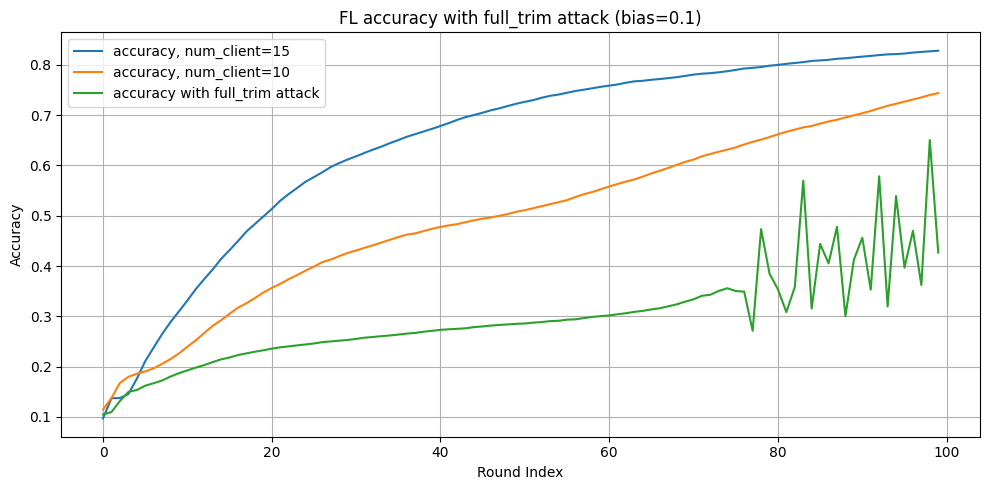

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_5_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_5_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.1)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### implementing full_trim defense

In [88]:
accuracy_bias_0_5_full_trim_defense = []
print(accuracy_bias_0_5_full_trim_defense)

[]


In [89]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    #agg_grads = torch.mean(user_grads, dim=0)
    agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_5_full_trim_defense.append(correct/total)

0 0.1088
1 0.105
2 0.1045
3 0.1062
4 0.1084
5 0.1104
6 0.1119
7 0.1145
8 0.1158
9 0.1189
10 0.121
11 0.1227
12 0.1242
13 0.127
14 0.1288
15 0.1309
16 0.1323
17 0.1343
18 0.1372
19 0.1403
20 0.1433
21 0.1453
22 0.1489
23 0.1521
24 0.1534
25 0.1566
26 0.16
27 0.1634
28 0.1669
29 0.1701
30 0.1735
31 0.1769
32 0.1813
33 0.1865
34 0.1898
35 0.1933
36 0.1978
37 0.2017
38 0.2053
39 0.2084
40 0.2113
41 0.2136
42 0.2162
43 0.219
44 0.2217
45 0.2238
46 0.2251
47 0.2267
48 0.2284
49 0.2301
50 0.2319
51 0.2332
52 0.2339
53 0.2345
54 0.2364
55 0.2375
56 0.2377
57 0.2386
58 0.2396
59 0.2406
60 0.2422
61 0.2431
62 0.244
63 0.2452
64 0.2461
65 0.247
66 0.2476
67 0.2485
68 0.249
69 0.2496
70 0.2504
71 0.2521
72 0.2533
73 0.2541
74 0.2553
75 0.2561
76 0.2569
77 0.2573
78 0.2577
79 0.2583
80 0.2594
81 0.2598
82 0.2603
83 0.2608
84 0.2617
85 0.2626
86 0.2634
87 0.2644
88 0.265
89 0.2659
90 0.2672
91 0.2682
92 0.2686
93 0.2698
94 0.271
95 0.2718
96 0.2724
97 0.2729
98 0.2738
99 0.2749
CPU times: user 1min 

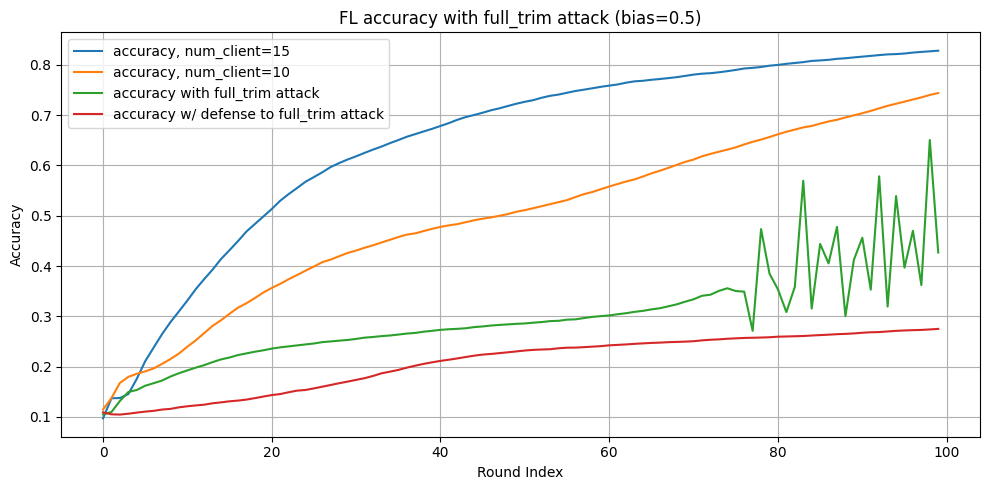

In [90]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_5, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_5_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_5_full_trim_attack, label='accuracy with full_trim attack')
plt.plot(accuracy_bias_0_5_full_trim_defense, label='accuracy w/ defense to full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.5)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# bias = 0.9, # of clients = 15
# ===============================

In [91]:
bias = 0.9
num_workers = 15 # number of clients
bias_weight = bias
other_group_size = (1 - bias_weight) / 9.
worker_per_group = num_workers / 10

In [92]:
#This code block is distributing the data amongst the clients. This is called the fang distribution
each_worker_data = [[] for _ in range(num_workers)]
each_worker_label = [[] for _ in range(num_workers)]
for i, (data, labels) in enumerate(train_data):
    for (x, y) in zip(data, labels):
        #print(np.shape(x))
        
        # assign a data point to a group
        upper_bound = (y) * (1 - bias_weight) / 9. + bias_weight
        lower_bound = (y) * (1 - bias_weight) / 9.
        rd = np.random.random_sample()

        if rd > upper_bound:
            worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)
        elif rd < lower_bound:
            worker_group = int(np.floor(rd / other_group_size))
        else:
            worker_group = y

        # assign a data point to a worker
        rd = np.random.random_sample()
        selected_worker = int(worker_group * worker_per_group + int(np.floor(rd * worker_per_group)))
        each_worker_data[selected_worker].append(x)
        each_worker_label[selected_worker].append(y)

/tmp/ipykernel_13480/904806604.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  worker_group = int(np.floor((rd - upper_bound) / other_group_size) + y + 1)


In [93]:
each_worker_data = [torch.stack(each_worker) for each_worker in each_worker_data]
each_worker_label = [torch.stack(each_worker) for each_worker in each_worker_label]

In [94]:
seed = 3
random_order = np.random.RandomState(seed=seed).permutation(num_workers)
each_worker_data = [each_worker_data[i] for i in random_order]
each_worker_label = [each_worker_label[i] for i in random_order]

In [95]:
each_worker_data = [each_worker.to(device) for each_worker in each_worker_data]
each_worker_label = [each_worker.to(device) for each_worker in each_worker_label]

### main code, save to accuracy_bias_0_9

In [96]:
accuracy_bias_0_9 = []
print(accuracy_bias_0_9)

[]


In [97]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9.append(correct/total)

0 0.0858
1 0.123
2 0.1484
3 0.1636
4 0.1764
5 0.2067
6 0.2713
7 0.2955
8 0.3098
9 0.3242
10 0.3376
11 0.3518
12 0.3636
13 0.3773
14 0.3885
15 0.3996
16 0.4114
17 0.4213
18 0.4327
19 0.4427
20 0.4526
21 0.4617
22 0.4717
23 0.4811
24 0.4912
25 0.5006
26 0.5084
27 0.518
28 0.5279
29 0.5373
30 0.5473
31 0.5582
32 0.5673
33 0.5754
34 0.5838
35 0.5931
36 0.6005
37 0.6079
38 0.6177
39 0.6261
40 0.6324
41 0.64
42 0.647
43 0.6559
44 0.6624
45 0.6678
46 0.6738
47 0.68
48 0.6868
49 0.6925
50 0.6982
51 0.7031
52 0.7059
53 0.7099
54 0.7149
55 0.7187
56 0.721
57 0.7267
58 0.73
59 0.7332
60 0.7369
61 0.7411
62 0.7442
63 0.7469
64 0.7503
65 0.7538
66 0.7586
67 0.7622
68 0.7651
69 0.7682
70 0.7717
71 0.7744
72 0.7771
73 0.7795
74 0.7822
75 0.7841
76 0.7882
77 0.7895
78 0.792
79 0.7948
80 0.797
81 0.7985
82 0.8006
83 0.8021
84 0.8046
85 0.8062
86 0.808
87 0.8108
88 0.8125
89 0.8137
90 0.816
91 0.818
92 0.82
93 0.8216
94 0.8233
95 0.8246
96 0.8264
97 0.8273
98 0.8283
99 0.8297
CPU times: user 2min 12s, s

### Displaying results, bias = 0.9. # of clients = 15

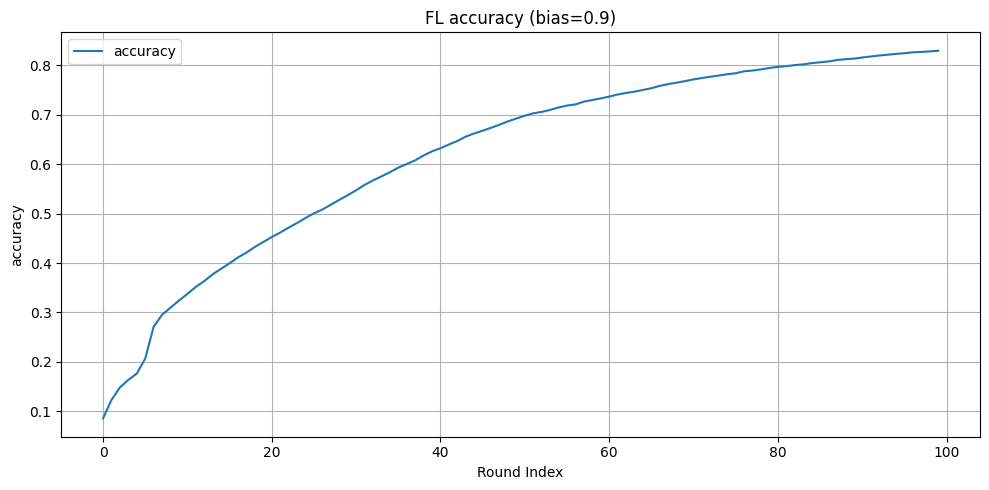

In [98]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9, label='accuracy')
plt.title('FL accuracy (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Lie attack on bias = 0.9

In [99]:
accuracy_bias_0_9_lie_attack = []
print(accuracy_bias_0_9_lie_attack)

[]


### saving to accuracy_bias_0_9_lie_attack

In [100]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads= lie_attack(user_grads, z)
    #agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9_lie_attack.append(correct/total)

0 0.1097
1 0.117
2 0.0981
3 0.0953
4 0.0952
5 0.0964
6 0.0957
7 0.0959
8 0.0969
9 0.0937
10 0.0947
11 0.0978
12 0.0987
13 0.1012
14 0.1011
15 0.1017
16 0.102
17 0.102
18 0.1023
19 0.102
20 0.1022
21 0.1025
22 0.1024
23 0.1025
24 0.1026
25 0.1026
26 0.1027
27 0.1028
28 0.1028
29 0.1028
30 0.1029
31 0.103
32 0.103
33 0.1031
34 0.1031
35 0.1031
36 0.1031
37 0.1031
38 0.1031
39 0.1031
40 0.1031
41 0.1031
42 0.1031
43 0.1031
44 0.1031
45 0.1031
46 0.1031
47 0.1031
48 0.1031
49 0.1031
50 0.1031
51 0.1031
52 0.1031
53 0.1032
54 0.1032
55 0.1032
56 0.1032
57 0.1032
58 0.1032
59 0.1032
60 0.1032
61 0.1032
62 0.1032
63 0.1032
64 0.1032
65 0.1032
66 0.1032
67 0.1032
68 0.1032
69 0.1032
70 0.1032
71 0.1032
72 0.1032
73 0.1032
74 0.1032
75 0.1032
76 0.1032
77 0.1032
78 0.1032
79 0.1032
80 0.1032
81 0.1032
82 0.1032
83 0.1032
84 0.1032
85 0.1032
86 0.1032
87 0.1032
88 0.1032
89 0.1032
90 0.1032
91 0.1032
92 0.1032
93 0.1032
94 0.1032
95 0.1032
96 0.1032
97 0.1032
98 0.1032
99 0.1032
CPU times: user 

### LIE Attack, bias = 0.9. # of clients = 15

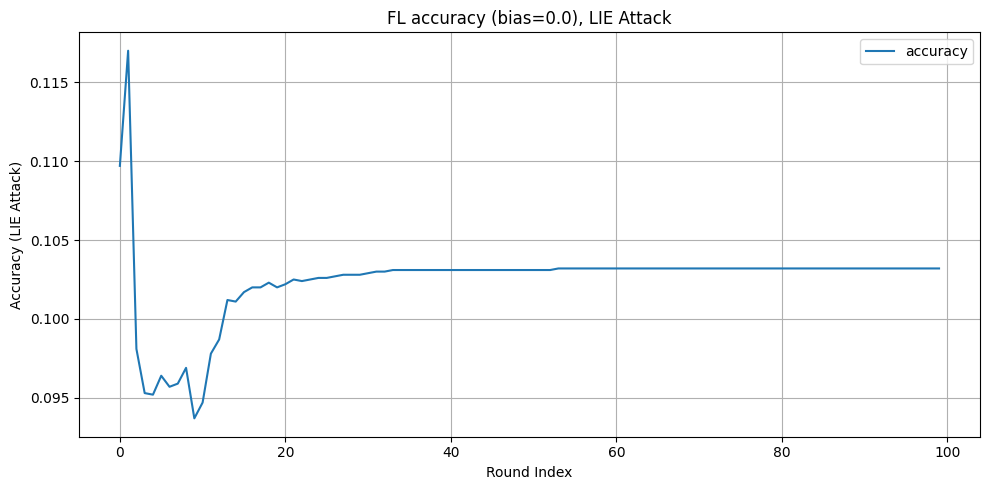

In [101]:
plt.figure(figsize=(10, 5))
plt.plot( accuracy_bias_0_9_lie_attack, label='accuracy')
plt.title('FL accuracy (bias=0.0), LIE Attack')
plt.xlabel('Round Index')
plt.ylabel('Accuracy (LIE Attack)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### both

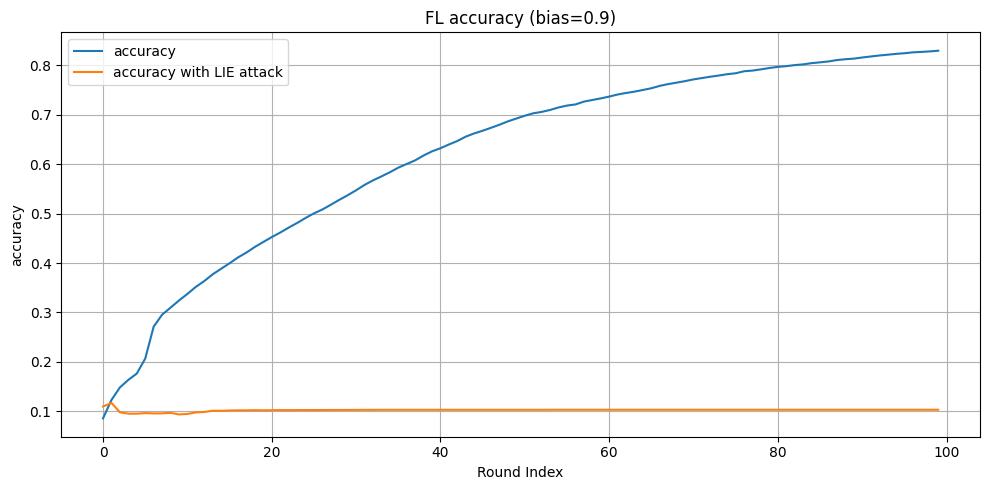

In [102]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9, label='accuracy')
plt.plot( accuracy_bias_0_9_lie_attack, label='accuracy with LIE attack')
plt.title('FL accuracy (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### full_trim attack, bias = 0.9

In [106]:
accuracy_bias_0_9_full_trim_attack = []
print(accuracy_bias_0_9_full_trim_attack)

[]


In [107]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    agg_grads = torch.mean(user_grads, dim=0)
    #agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9_full_trim_attack.append(correct/total)

0 0.1437
1 0.1501
2 0.1547
3 0.1611
4 0.1644
5 0.1709
6 0.1735
7 0.1797
8 0.1815
9 0.1859
10 0.1877
11 0.1915
12 0.1944
13 0.1953
14 0.1972
15 0.1987
16 0.1998
17 0.2008
18 0.2012
19 0.2021
20 0.2015
21 0.2012
22 0.2015
23 0.2012
24 0.2025
25 0.2036
26 0.204
27 0.2053
28 0.2062
29 0.2075
30 0.2099
31 0.212
32 0.2128
33 0.2151
34 0.2142
35 0.2114
36 0.1841
37 0.1536
38 0.096
39 0.096
40 0.0974
41 0.1814
42 0.1889
43 0.2145
44 0.1188
45 0.1722
46 0.1033
47 0.1378
48 0.1226
49 0.1735
50 0.1767
51 0.2001
52 0.2479
53 0.1655
54 0.2293
55 0.1168
56 0.1764
57 0.1076
58 0.1861
59 0.2026
60 0.2469
61 0.2506
62 0.2594
63 0.239
64 0.2648
65 0.2353
66 0.2668
67 0.2542
68 0.2333
69 0.1879
70 0.1301
71 0.1086
72 0.1587
73 0.184
74 0.249
75 0.2512
76 0.1857
77 0.1703
78 0.1019
79 0.1742
80 0.2903
81 0.252
82 0.2467
83 0.2024
84 0.1682
85 0.1088
86 0.1246
87 0.2323
88 0.2289
89 0.2361
90 0.2064
91 0.2067
92 0.1216
93 0.1899
94 0.3493
95 0.3097
96 0.3266
97 0.3041
98 0.3132
99 0.2455
CPU times: user 2m

### full_trim attack, bias = 0.9, 15 clients

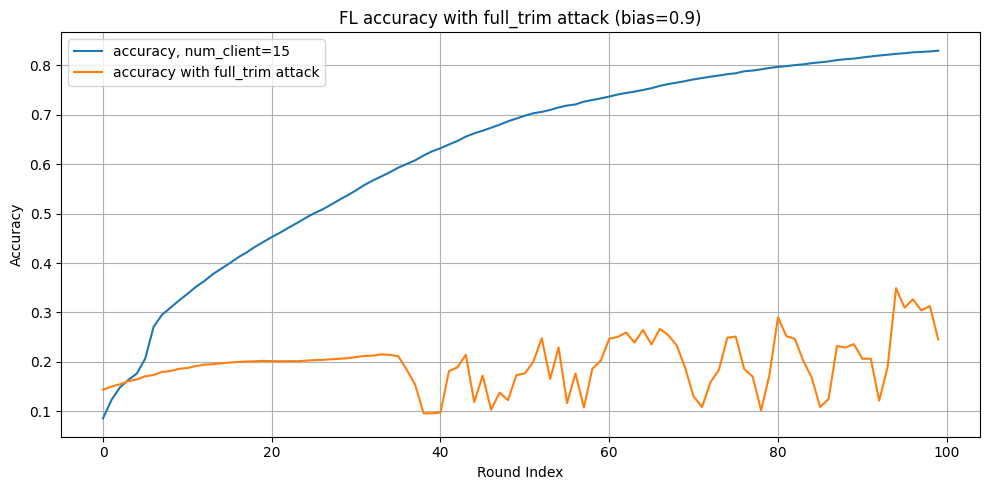

In [108]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_9_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### now with 10 clients, normal run, no full_trim attack, save to accuracy_bias_0_9_clients_10

In [109]:
accuracy_bias_0_9_clients_10 = []
print(accuracy_bias_0_9_clients_10)

[]


In [110]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
for e in range(100):
    cnn_optimizer = SGD(net.parameters(), lr = lr*(0.999**e))
    user_grads = []

    # for each worker
    for i in range(10):
        net_ = copy.deepcopy(net)
        net_.zero_grad()
        output = net_(each_worker_data[i][:])
        loss = criterion(output, each_worker_label[i][:])

        # backward
        loss.backward()

        param_grad=[]
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    #This is the average function. We are taking average of all the client model updates

    if len(user_grads)==0:
        continue
    agg_grads=torch.mean(user_grads,dim=0)

    del user_grads

    start_idx=0
    cnn_optimizer.zero_grad()
    model_grads=[]
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)

    #Applying the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    total, correct = 0,0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9_clients_10.append(correct/total)

0 0.1207
1 0.1446
2 0.1839
3 0.1942
4 0.1981
5 0.2046
6 0.2123
7 0.221
8 0.2303
9 0.2403
10 0.2502
11 0.2624
12 0.2732
13 0.2838
14 0.2944
15 0.3022
16 0.3102
17 0.3182
18 0.3262
19 0.3333
20 0.3398
21 0.346
22 0.3504
23 0.3553
24 0.3602
25 0.3658
26 0.3694
27 0.3739
28 0.3778
29 0.3834
30 0.3888
31 0.3945
32 0.4009
33 0.4075
34 0.4135
35 0.4187
36 0.4244
37 0.4294
38 0.4349
39 0.4411
40 0.4469
41 0.4526
42 0.4581
43 0.4632
44 0.4684
45 0.4729
46 0.4781
47 0.4832
48 0.486
49 0.49
50 0.4935
51 0.498
52 0.5021
53 0.5048
54 0.5082
55 0.5128
56 0.5165
57 0.52
58 0.5227
59 0.5265
60 0.5295
61 0.5315
62 0.5336
63 0.5365
64 0.5398
65 0.5421
66 0.5436
67 0.5459
68 0.5483
69 0.5512
70 0.5541
71 0.5561
72 0.5582
73 0.5615
74 0.5631
75 0.5666
76 0.5687
77 0.5705
78 0.5723
79 0.5744
80 0.5773
81 0.5796
82 0.5817
83 0.5833
84 0.5867
85 0.5894
86 0.5917
87 0.5943
88 0.5973
89 0.5991
90 0.6012
91 0.6042
92 0.607
93 0.6103
94 0.614
95 0.618
96 0.6221
97 0.6255
98 0.6288
99 0.6331
CPU times: user 1min 

### 3 graphs for full_trim, bias = 0.9

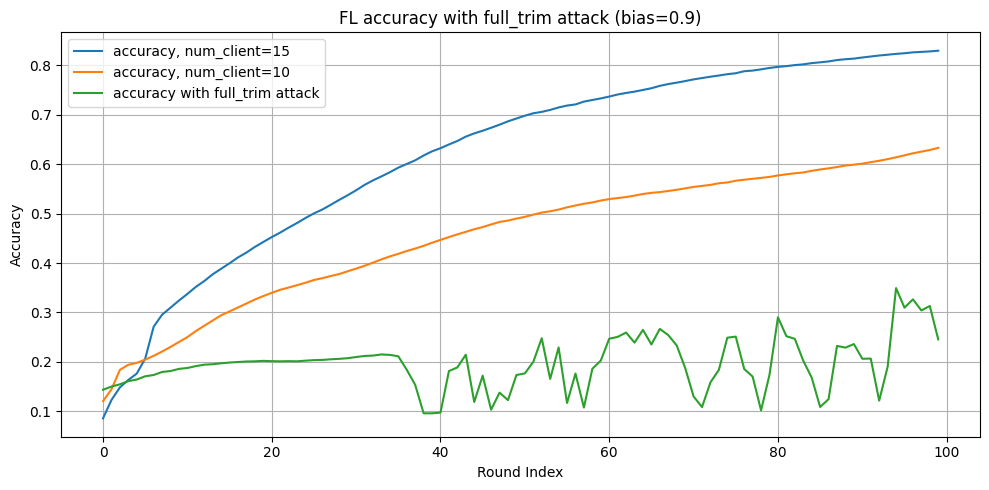

In [111]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_9_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_9_full_trim_attack, label='accuracy with full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### implementing full_trim defense

In [112]:
accuracy_bias_0_9_full_trim_defense = []
print(accuracy_bias_0_9_full_trim_defense)

[]


In [113]:
%%time

### begin training
import pickle
net = cnn().to(device)
gain = 1
net.apply(init_weights)

lr = 0.01
compromised_workers = 3  
for e in range(100):  
    cnn_optimizer = SGD(net.parameters(), lr=lr * (0.999**e))
    user_grads = []

    # for each worker
    for i in range(num_workers):
        net_ = copy.deepcopy(net)  
        net_.zero_grad()  
        output = net_(each_worker_data[i][:])  
        loss = criterion(output, each_worker_label[i][:])  
        
        # backward
        loss.backward() 

        param_grad = []
        for param in net_.parameters():
            param_grad=param.grad.data.view(-1) if not len(param_grad) else torch.cat((param_grad,param.grad.view(-1)))

        user_grads=param_grad[None, :] if len(user_grads)==0 else torch.cat((user_grads,param_grad[None,:]), 0)

        del net_

    if len(user_grads) == 0:
        continue

    # Apply Full-Knowledge Trim Attack to the gradients
    user_grads = full_trim(user_grads, compromised_workers)

    #This is the average function. We are taking average of all the client model updates
    #agg_grads = torch.mean(user_grads, dim=0)
    agg_grads = tr_mean(user_grads, compromised_workers)

    del user_grads

    start_idx = 0
    cnn_optimizer.zero_grad()
    model_grads = []
    for i, param in enumerate(net.parameters()):
        param_=agg_grads[start_idx:start_idx+len(param.data.view(-1))].reshape(param.data.shape)
        start_idx=start_idx+len(param.data.view(-1))
        param_=param_.cuda()
        model_grads.append(param_)
        
    # Apply the aggregated model update to the server
    cnn_optimizer.step(model_grads)

    # Evaluate the model
    total, correct = 0, 0
    with torch.no_grad():
        for i, data in enumerate(test_data):
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = net(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(e,correct/total)
    accuracy_bias_0_9_full_trim_defense.append(correct/total)

0 0.0969
1 0.0999
2 0.1027
3 0.103
4 0.1032
5 0.1035
6 0.1036
7 0.1035
8 0.1035
9 0.1033
10 0.1037
11 0.1037
12 0.1029
13 0.1027
14 0.1024
15 0.1022
16 0.1018
17 0.1016
18 0.1023
19 0.1019
20 0.1008
21 0.1016
22 0.1014
23 0.1015
24 0.1005
25 0.1013
26 0.102
27 0.1016
28 0.1021
29 0.1023
30 0.1028
31 0.1038
32 0.1048
33 0.1048
34 0.1059
35 0.1068
36 0.1069
37 0.1077
38 0.1085
39 0.109
40 0.1092
41 0.1099
42 0.1111
43 0.1132
44 0.1125
45 0.1131
46 0.1133
47 0.1139
48 0.1145
49 0.1147
50 0.1156
51 0.1154
52 0.1154
53 0.1163
54 0.1169
55 0.1176
56 0.1199
57 0.1219
58 0.1258
59 0.1291
60 0.1312
61 0.135
62 0.1388
63 0.1417
64 0.1449
65 0.1469
66 0.1492
67 0.1518
68 0.1531
69 0.1557
70 0.1563
71 0.1588
72 0.159
73 0.1604
74 0.1612
75 0.1623
76 0.1625
77 0.164
78 0.165
79 0.1646
80 0.167
81 0.1651
82 0.1662
83 0.165
84 0.1675
85 0.1621
86 0.1703
87 0.1517
88 0.1844
89 0.0174
90 0.1567
91 0.057
92 0.1028
93 0.1284
94 0.045
95 0.0957
96 0.0335
97 0.0602
98 0.0448
99 0.0976
CPU times: user 2min 

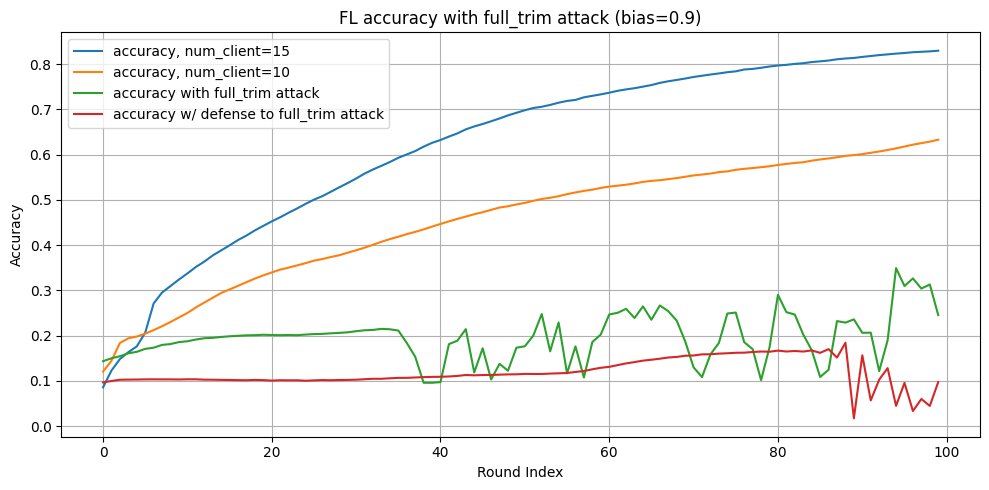

In [114]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_9, label='accuracy, num_client=15')
plt.plot(accuracy_bias_0_9_clients_10, label='accuracy, num_client=10')
plt.plot(accuracy_bias_0_9_full_trim_attack, label='accuracy with full_trim attack')
plt.plot(accuracy_bias_0_9_full_trim_defense, label='accuracy w/ defense to full_trim attack')

plt.title('FL accuracy with full_trim attack (bias=0.9)')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Graphing all

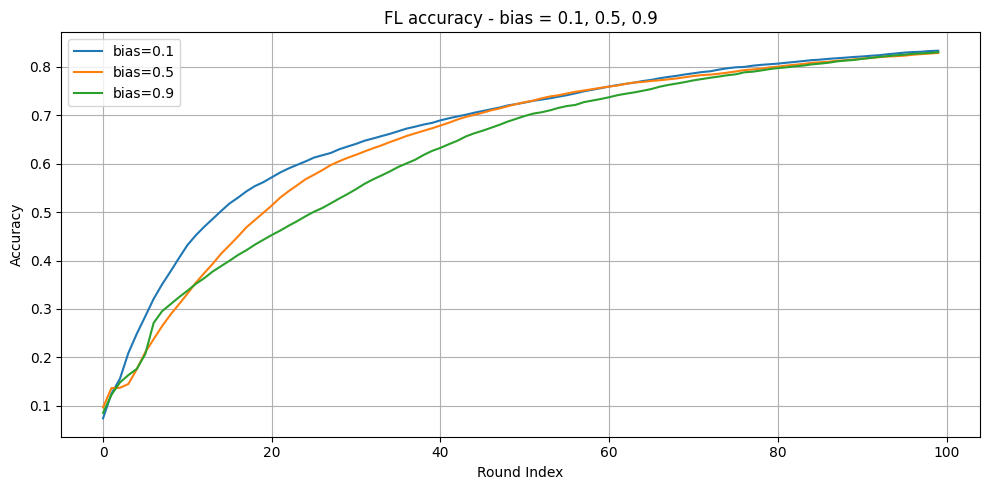

In [115]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_bias_0_1, label="bias=0.1")
plt.plot(accuracy_bias_0_5, label="bias=0.5")
plt.plot(accuracy_bias_0_9, label="bias=0.9")
plt.title('FL accuracy - bias = 0.1, 0.5, 0.9')
plt.xlabel('Round Index')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()